In [1]:
# /// script
# dependencies = [
#   "earth2studio[dlwp] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การวินิจฉัยแบบกำหนดเอง
ตามที่กล่าวไว้ในส่วน `diagnostic_model_userguide` ของคู่มือผู้ใช้
Earth2Studio กำหนด Diagnostic Model ผ่านอินเทอร์เฟซที่เรียบง่าย
:py:class:`earth2studio.models.dx.base.Diagnostic Model`. สามารถใช้เพื่อช่วยได้
แนะนำ API ที่จำเป็นซึ่งจำเป็นในการสร้างโมเดลของเราเองได้สำเร็จ

ในตัวอย่างนี้ ให้พิจารณาการวินิจฉัยง่ายๆ ที่แปลงพื้นผิว
อุณหภูมิเป็นเคลวินถึงเซลเซียสเพื่อให้คนทั่วไปอ่านได้ง่ายขึ้น

Diagnostic Model ของเรามีคลาสพื้นฐานเป็น :py:class:`torch.nn.Module` ซึ่งช่วยให้เราทำได้
เพื่อรับวิธี :py:obj:`to(device)` ที่จำเป็นฟรี



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from collections import OrderedDict

import numpy as np
import torch

from earth2studio.models.batch import batch_coords, batch_func
from earth2studio.utils import handshake_coords, handshake_dim
from earth2studio.utils.type import CoordSystem


class CustomDiagnostic(torch.nn.Module):
    """Custom dianostic model"""

    def __init__(self):
        super().__init__()

    def input_coords(self) -> CoordSystem:
        """Input coordinate system of the prognostic model

        Returns
        -------
        CoordSystem
            Coordinate system dictionary
        """
        return OrderedDict(
            {
                "batch": np.empty(0),
                "variable": np.array(["t2m"]),
                "lat": np.linspace(90, -90, 721),
                "lon": np.linspace(0, 360, 1440, endpoint=False),
            }
        )

    @batch_coords()
    def output_coords(self, input_coords: CoordSystem) -> CoordSystem:
        """Output coordinate system of the prognostic model

        Parameters
        ----------
        input_coords : CoordSystem
            Input coordinate system to transform into output_coords

        Returns
        -------
        CoordSystem
            Coordinate system dictionary
        """
        # ตรวจสอบพิกัดอินพุตว่าถูกต้อง
        target_input_coords = self.input_coords()
        for i, (key, value) in enumerate(target_input_coords.items()):
            if key != "batch":
                handshake_dim(input_coords, key, i)
                handshake_coords(input_coords, target_input_coords, key)

        output_coords = OrderedDict(
            {
                "batch": np.empty(0),
                "variable": np.array(["t2m_c"]),
                "lat": np.linspace(90, -90, 721),
                "lon": np.linspace(0, 360, 1440, endpoint=False),
            }
        )
        output_coords["batch"] = input_coords["batch"]
        return output_coords

    @batch_func()
    def __call__(
        self,
        x: torch.Tensor,
        coords: CoordSystem,
    ) -> tuple[torch.Tensor, CoordSystem]:
        """Runs diagnostic model

        Parameters
        ----------
        x : torch.Tensor
            Input tensor
        coords : CoordSystem
            Input coordinate system
        """
        out_coords = self.output_coords(coords)
        out = x - 273.15  # ถึงเซลเซียส
        return out, out_coords

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


### พิกัดอินพุต/เอาต์พุต
การกำหนดระบบพิกัดอินพุต/เอาต์พุตเป็นสิ่งจำเป็นสำหรับโมเดลใดๆ ใน
Earth2Studio เนื่องจากนี่คือวิธีที่ทั้งแพ็กเกจและผู้ใช้สามารถเรียนรู้ว่าข้อมูลประเภทใด
โมเดลคาดหวัง สิ่งนี้ต้องการคำจำกัดความของ :py:func:`input_coords` และ
:py:func:`output_coords`. ดูรายละเอียดที่ `coordinates_userguide`
ระบบพิกัด

สำหรับ Diagnostic Model นี้ เราเพียงแค่กำหนดพิกัดอินพุต
ให้เป็นอุณหภูมิพื้นผิวโลกที่ระบุใน :file:`earth2studio.lexicon.base.py`
เอาต์พุตเป็นตัวแปรที่กำหนดเอง :code:`t2m_c` ที่แสดงอุณหภูมิใน
เซลเซียส.



### API ของ :py:func:`__call__`
ฟังก์ชั่นการโทรเป็น API หลักของโมเดลการวินิจฉัยที่มีเทนเซอร์และ
ระบบพิกัดเป็นอินพุต/เอาต์พุต ฟังก์ชันนี้จะตรวจสอบความถูกต้องของพิกัดก่อน
ระบบถูกต้อง จากนั้นทั้งเทนเซอร์ข้อมูลอินพุตและระบบพิกัดก็เช่นกัน
อัปเดตและส่งคืน

<div class="alert alert-info"><h4>หมายเหตุ</h4><p>คุณอาจสังเกตเห็นเครื่องมือตกแต่ง :py:func:`batch_func` ซึ่งใช้ในการสร้าง batched
การดำเนินงานได้ง่ายขึ้น สำหรับรายละเอียดเพิ่มเติมเกี่ยวกับสิ่งนี้ โปรดดูที่ `batch_function_userguide`
ส่วนของคู่มือผู้ใช้</p></div>



## การเตรียมองค์ประกอบ
ด้วยการกำหนด Diagnostic Model แบบกำหนดเอง ขั้นตอนถัดไปคือการตั้งค่าและรัน a
workflow. เราจะใช้ workflow :py:meth:`earth2studio.run.diagnostic` ในตัว



ให้ยกตัวอย่างส่วนประกอบที่จำเป็น

- Prognostic Model: ใช้ DLWP รุ่น :py:class:`earth2studio.models.px.DLWP` ในตัว
- Diagnostic Model: Diagnostic Model แบบกำหนดเองที่กำหนดไว้ข้างต้น
- Datasource: ดึงข้อมูลจาก GFS data API ผ่าน :py:class:`earth2studio.data.GFS`.
- IO Backend: บันทึกเอาต์พุตลงในร้านค้า Zarr :py:class:`earth2studio.io.ZarrBackend`



In [3]:
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.px import DLWP

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = DLWP.load_default_package()
model = DLWP.load_model(package)

# Diagnostic Model
diagnostic = CustomDiagnostic()

# สร้างแหล่งข้อมูล
data = GFS()

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
io = ZarrBackend()

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


## การรัน Workflow
การรัน workflow ของเราด้วยบิลด์ใน Prognostic Model และการวินิจฉัยแบบกำหนดเองคือ
เช่นเดียวกับการรันการวินิจฉัยในตัว



In [4]:
import earth2studio.run as run

nsteps = 20
io = run.diagnostic(["2024-01-01"], nsteps, model, diagnostic, data, io)

print(io.root.tree())

2026-04-26 21:11:18.344 | INFO     | earth2studio.run:diagnostic:198 - Running diagnostic workflow!
2026-04-26 21:11:18.344 | INFO     | earth2studio.run:diagnostic:205 - Inference device: cuda


Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 79.64it/s]


2026-04-26 21:11:18.692 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 397402829-996456
2026-04-26 21:11:18.710 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 420029701-1181204
2026-04-26 21:11:18.723 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 251230645-803982
2026-04-26 21:11:18.735 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 408062467-879185
2026-04-26 21:11:18.746 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231231/18/atmos/gfs.t18z.pgrb2.0p25.f000 329116923-847018
2026-04-26 21:11:18.757 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-26 21:11:18.813 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 289307267-851916
2026-04-26 21:11:18.824 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 414179964-1179422
2026-04-26 21:11:18.837 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 246334297-805355
2026-04-26 21:11:18.849 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 402321768-876246
2026-04-26 21:11:18.861 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240101/00/atmos/gfs.t00z.pgrb2.0p25.f000 323956279-837771
2026-04-26 21:11:18.873 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 84.30it/s]


2026-04-26 21:11:18.912 | SUCCESS  | earth2studio.run:diagnostic:228 - Fetched data from GFS
2026-04-26 21:11:18.921 | INFO     | earth2studio.run:diagnostic:260 - Inference starting!


Running inference: 100%|██████████| 21/21 [00:01<00:00, 20.34it/s]

2026-04-26 21:11:19.955 | SUCCESS  | earth2studio.run:diagnostic:276 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (21,) timedelta64[h]
├── lon (1440,) float64
├── t2m_c (1, 21, 721, 1440) float32
└── time (1,) datetime64[ns]



## การทำ Post-Processing
เรามาพล็อตฟิลด์อุณหภูมิเซลเซียสจาก Diagnostic Model ที่เรากำหนดเองกัน



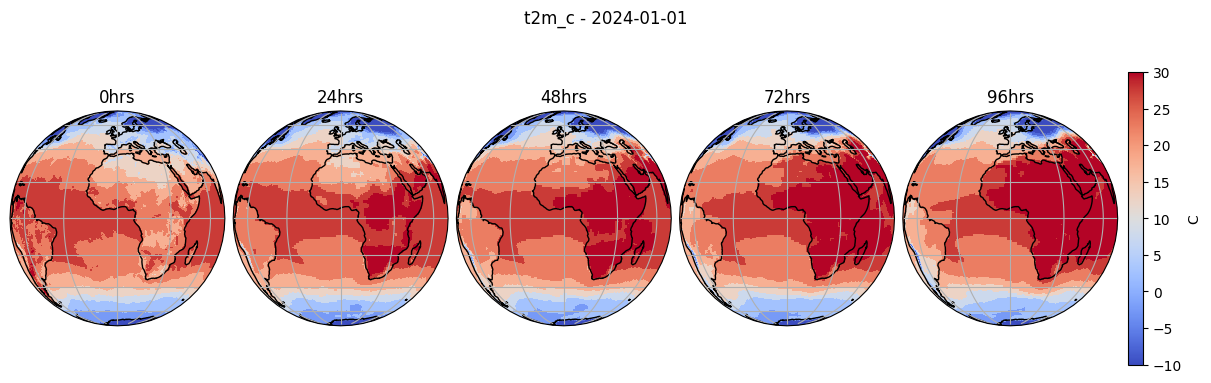

In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

forecast = "2024-01-01"
variable = "t2m_c"

plt.close("all")

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, ax = plt.subplots(
    1,
    5,
    figsize=(12, 4),
    subplot_kw={"projection": ccrs.Orthographic()},
    constrained_layout=True,
)

times = (
    io["lead_time"][:].astype("timedelta64[ns]").astype("timedelta64[h]").astype(int)
)
step = 4  # 24ชม
for i, t in enumerate(range(0, 20, step)):

    ctr = ax[i].contourf(
        io["lon"][:],
        io["lat"][:],
        io[variable][0, t],
        vmin=-10,
        vmax=30,
        transform=ccrs.PlateCarree(),
        levels=20,
        cmap="coolwarm",
    )
    ax[i].set_title(f"{times[t]}hrs")
    ax[i].coastlines()
    ax[i].gridlines()

plt.suptitle(f"{variable} - {forecast}")

cbar = plt.cm.ScalarMappable(cmap="coolwarm")
cbar.set_array(io[variable][0, 0])
cbar.set_clim(-10.0, 30)
cbar = fig.colorbar(cbar, ax=ax[-1], orientation="vertical", label="C", shrink=0.8)


plt.savefig("outputs/02_custom_diagnostic_dlwp_prediction.jpg")